<a href="https://colab.research.google.com/github/abhishekraman2001/AI-Health/blob/main/akr3222_Self_Learning__Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting ICU Length of Stay in Diabetic Patients Using MIMIC-III and Machine Learning

## Tutorial Objective
In this project, we:
1. Identify diabetic ICU patients from MIMIC-III structured data
2. Engineer simple clinical and demographic features
3. Predict ICU length-of-stay category using machine learning

## Problem Statement
Diabetes is a common chronic disease that can complicate hospitalization and ICU care. This tutorial demonstrates how structured EHR data can be used to classify ICU stay into:

 **Short stay**: less than 2 days  
 **Medium stay**: 2 to 7 days  
 **Long stay**: more than 7 days  

## Notes
 I designed the notebook to be easy to teach and easy to follow.
  The `BASE_DIR` cell includes the local data path you provided.


## 4. Build a quick cohort based on raw MIMIC CSV files

If `diabetic_icu_cohort.csv` does not exist, the cell below shows a **fallback Python workflow, that can build a basic cohort from raw MIMIC tables.


 `PATIENTS.csv.gz`
 `ADMISSIONS.csv.gz`
 `ICUSTAYS.csv.gz`
 `DIAGNOSES_ICD.csv.gz`

are inside your data directory.

Create file **diabetic_icu_cohort** add elements

    1. "subject_id",
    2. "hadm_id",
    3. "icustay_id",
    4. "gender",
    5. "age_at_icu",
    6. "admission_type",
    7. "insurance",
    8. "ethnicity",
    9. "los",
    10. "num_diagnoses"
#-------------------

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path
import pandas as pd

def read_csv_auto(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, compression="infer", low_memory=False)

BASE_DIR = Path(r"/content/drive/MyDrive/akr3222_hw4/")
COHORT_FILE = BASE_DIR / "diabetic_icu_cohort.csv"

patients = read_csv_auto(BASE_DIR / "PATIENTS.csv")
admissions = read_csv_auto(BASE_DIR / "ADMISSIONS.csv")
icustays = read_csv_auto(BASE_DIR / "ICUSTAYS.csv")
diagnoses = read_csv_auto(BASE_DIR / "DIAGNOSES_ICD.csv")

diagnoses.columns = diagnoses.columns.str.lower()

diabetes_hadm = diagnoses.loc[
    diagnoses["icd9_code"].astype(str).str.startswith("250", na=False),
    ["subject_id", "hadm_id"]
].drop_duplicates()

cohort = (
    diabetes_hadm
    .merge(admissions, on=["subject_id", "hadm_id"], how="inner")
    .merge(icustays, on=["subject_id", "hadm_id"], how="inner")
    .merge(patients[["subject_id", "gender", "dob"]], on="subject_id", how="left")
)

cohort["intime"] = pd.to_datetime(cohort["intime"], errors="coerce")
cohort["dob"] = pd.to_datetime(cohort["dob"], errors="coerce")

# Safe age calculation
cohort["age_at_icu"] = cohort["intime"].dt.year - cohort["dob"].dt.year

birthday_not_passed = (
    (cohort["intime"].dt.month < cohort["dob"].dt.month) |
    (
        (cohort["intime"].dt.month == cohort["dob"].dt.month) &
        (cohort["intime"].dt.day < cohort["dob"].dt.day)
    )
)

cohort.loc[birthday_not_passed, "age_at_icu"] = cohort.loc[birthday_not_passed, "age_at_icu"] - 1
cohort["age_at_icu"] = cohort["age_at_icu"].astype(float)

# Cap deidentified elderly ages
cohort.loc[cohort["age_at_icu"] > 89, "age_at_icu"] = 90
cohort = cohort[(cohort["age_at_icu"].isna()) | (cohort["age_at_icu"] >= 0)]

diag_counts = diagnoses.groupby("hadm_id").size().rename("num_diagnoses").reset_index()
cohort = cohort.merge(diag_counts, on="hadm_id", how="left")

keep_cols = [
    "subject_id",
    "hadm_id",
    "icustay_id",
    "gender",
    "age_at_icu",
    "admission_type",
    "insurance",
    "ethnicity",
    "los",
    "num_diagnoses"
]

cohort = cohort[[c for c in keep_cols if c in cohort.columns]].copy()

cohort.to_csv(COHORT_FILE, index=False)
print("Saved cohort to:", COHORT_FILE)
print("Cohort shape:", cohort.shape)
print(cohort.head())

Saved cohort to: /content/drive/MyDrive/akr3222_hw4/diabetic_icu_cohort.csv
Cohort shape: (51, 10)
   subject_id  hadm_id  icustay_id gender  age_at_icu admission_type  \
0       10033   157235      254543      F        81.0      EMERGENCY   
1       10045   126949      203766      F        68.0      EMERGENCY   
2       10006   142345      206504      F        70.0      EMERGENCY   
3       10094   122928      273347      M        90.0      EMERGENCY   
4       10094   168074      243600      M        90.0      EMERGENCY   

  insurance               ethnicity     los  num_diagnoses  
0  Medicare                   WHITE  1.0695             12  
1  Medicare                   WHITE  6.3034             27  
2  Medicare  BLACK/AFRICAN AMERICAN  1.6325             21  
3  Medicare  BLACK/AFRICAN AMERICAN  3.9712              8  
4  Medicare  BLACK/AFRICAN AMERICAN  4.1014             12  



## 1. Importing the libraries for all action data handelingh, chart

We import:
  1. **pandas / numpy** for data handling,
  2. **matplotlib / seaborn** for charts,
  3. **scikit-learn** for preprocessing, modeling, and evaluation.

# ============================================================
# Step 1: Import required libraries
# ============================================================

In [7]:



import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", 100)
sns.set_context("talk")

In [8]:
print("PATIENTS columns:\n", patients.columns.tolist())
print("ADMISSIONS columns:\n", admissions.columns.tolist())
print("ICUSTAYS columns:\n", icustays.columns.tolist())
print("DIAGNOSES columns:\n", diagnoses.columns.tolist())

PATIENTS columns:
 ['row_id', 'subject_id', 'gender', 'dob', 'dod', 'dod_hosp', 'dod_ssn', 'expire_flag']
ADMISSIONS columns:
 ['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis', 'hospital_expire_flag', 'has_chartevents_data']
ICUSTAYS columns:
 ['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'dbsource', 'first_careunit', 'last_careunit', 'first_wardid', 'last_wardid', 'intime', 'outtime', 'los']
DIAGNOSES columns:
 ['row_id', 'subject_id', 'hadm_id', 'seq_num', 'icd9_code']


## 2. Build or load the diabetic ICU cohort

In [9]:


if not COHORT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {COHORT_FILE}.\n"
        "Export your diabetes ICU cohort to this location or update COHORT_FILE."
    )

df = pd.read_csv(COHORT_FILE)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (51, 10)


,subject_id,hadm_id,icustay_id,gender,age_at_icu,admission_type,insurance,ethnicity,los,num_diagnoses
0,10033,157235,254543,F,81.0,EMERGENCY,Medicare,WHITE,1.0695,12
1,10045,126949,203766,F,68.0,EMERGENCY,Medicare,WHITE,6.3034,27
2,10006,142345,206504,F,70.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,1.6325,21
3,10094,122928,273347,M,90.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,3.9712,8
4,10094,168074,243600,M,90.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,4.1014,12


## 3. Inspect the data

Before modeling, we inspect:
1. shape,
2. column names,
3. missing values,
4. data types,
5. summary statistics.

This helps us find data quality issues early.

In [10]:



print(df.info())
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      51 non-null     int64  
 1   hadm_id         51 non-null     int64  
 2   icustay_id      51 non-null     int64  
 3   gender          51 non-null     object 
 4   age_at_icu      51 non-null     float64
 5   admission_type  51 non-null     object 
 6   insurance       51 non-null     object 
 7   ethnicity       51 non-null     object 
 8   los             51 non-null     float64
 9   num_diagnoses   51 non-null     int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 4.1+ KB
None

Missing values per column:


,0
subject_id,0
hadm_id,0
icustay_id,0
gender,0
age_at_icu,0
admission_type,0
insurance,0
ethnicity,0
los,0
num_diagnoses,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,51.0,NaN,NaN,NaN,32182.254902,15109.719376,10006.0,10124.0,41976.0,42245.5,44222.0
hadm_id,51.0,NaN,NaN,NaN,153998.117647,25720.296922,100969.0,135707.5,155297.0,174801.0,199395.0
icustay_id,51.0,NaN,NaN,NaN,252981.490196,30694.235376,203766.0,223032.0,253931.0,284226.5,298685.0
gender,51,2,M,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_at_icu,51.0,NaN,NaN,NaN,72.078431,12.271664,41.0,63.5,72.0,83.0,90.0
admission_type,51,3,EMERGENCY,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,51,3,Medicare,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,51,5,WHITE,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
los,51.0,NaN,NaN,NaN,4.444031,5.435864,0.535,1.1912,2.1436,5.0798,29.2601
num_diagnoses,51.0,NaN,NaN,NaN,16.509804,6.126573,5.0,12.0,17.0,20.0,37.0


In [11]:
print(df.columns.tolist())

['subject_id', 'hadm_id', 'icustay_id', 'gender', 'age_at_icu', 'admission_type', 'insurance', 'ethnicity', 'los', 'num_diagnoses']


## 5. Clean and standardize columns

\

In [12]:



df.columns = [c.strip().lower() for c in df.columns]

rename_candidates = {
    "los_days": "los",
    "gender_clean": "gender",
    "age": "age_at_icu"
}

for old, new in rename_candidates.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

required_candidates = ["los"]
missing_critical = [c for c in required_candidates if c not in df.columns]
if missing_critical:
    raise ValueError(f"Missing critical columns: {missing_critical}")

print("Columns after standardization:")
print(df.columns.tolist())

Columns after standardization:
['subject_id', 'hadm_id', 'icustay_id', 'gender', 'age_at_icu', 'admission_type', 'insurance', 'ethnicity', 'los', 'num_diagnoses']


## 6. Data cleaning



In [13]:


# Clean age if available
if "age_at_icu" in df.columns:
    df = df[df["age_at_icu"].notnull()]
    df = df[(df["age_at_icu"] >= 18) & (df["age_at_icu"] <= 100)]

# Clean LOS
df = df[df["los"].notnull()]
df = df[df["los"] >= 0]

# Remove duplicate ICU stays if they exist
dedup_cols = [c for c in ["subject_id", "hadm_id", "icustay_id"] if c in df.columns]
if dedup_cols:
    df = df.drop_duplicates(subset=dedup_cols)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (51, 10)


,subject_id,hadm_id,icustay_id,gender,age_at_icu,admission_type,insurance,ethnicity,los,num_diagnoses
0,10033,157235,254543,F,81.0,EMERGENCY,Medicare,WHITE,1.0695,12
1,10045,126949,203766,F,68.0,EMERGENCY,Medicare,WHITE,6.3034,27
2,10006,142345,206504,F,70.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,1.6325,21
3,10094,122928,273347,M,90.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,3.9712,8
4,10094,168074,243600,M,90.0,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,4.1014,12


## 7. Create the target variable



LOS category counts:


,count
los_category,
0,24
1,16
2,11


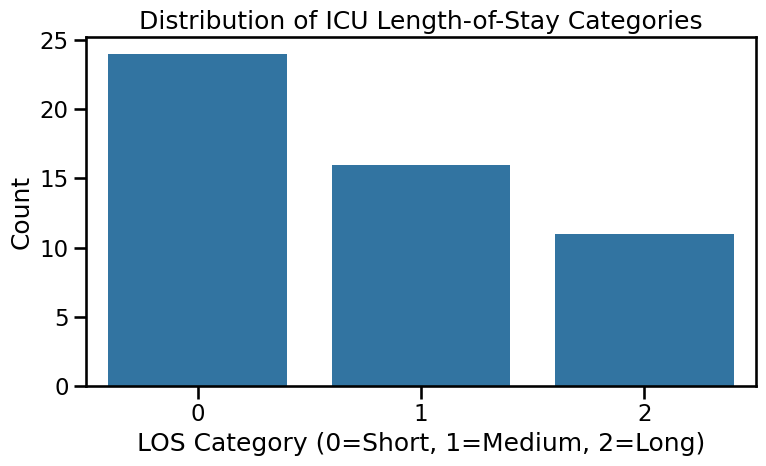

In [14]:


def categorize_los(los: float) -> int:
    if los < 2:
        return 0
    elif los <= 7:
        return 1
    else:
        return 2

df["los_category"] = df["los"].apply(categorize_los)

print("LOS category counts:")
display(df["los_category"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="los_category")
plt.title("Distribution of ICU Length-of-Stay Categories")
plt.xlabel("LOS Category (0=Short, 1=Medium, 2=Long)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 8. Explore features



In [15]:


candidate_features = [
    "age_at_icu",
    "gender",
    "admission_type",
    "insurance",
    "ethnicity",
    "num_diagnoses"
]

feature_cols = [c for c in candidate_features if c in df.columns]
if not feature_cols:
    raise ValueError("No expected feature columns were found in the dataset.")

X = df[feature_cols].copy()
y = df["los_category"].copy()

print("Selected features:", feature_cols)
display(X.head())

Selected features: ['age_at_icu', 'gender', 'admission_type', 'insurance', 'ethnicity', 'num_diagnoses']


,age_at_icu,gender,admission_type,insurance,ethnicity,num_diagnoses
0,81.0,F,EMERGENCY,Medicare,WHITE,12
1,68.0,F,EMERGENCY,Medicare,WHITE,27
2,70.0,F,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,21
3,90.0,M,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,8
4,90.0,M,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,12


## 9. Inspect feature types

Machine learning models need numerical and categorical features handled differently, so we separate them before preprocessing.

In [16]:


numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age_at_icu', 'num_diagnoses']
Categorical features: ['gender', 'admission_type', 'insurance', 'ethnicity']


## 10. Build the preprocessing pipeline

#

In [17]:


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 11. Train/test split



In [18]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
display(y_train.value_counts(normalize=True).sort_index())
print("y_test distribution:")
display(y_test.value_counts(normalize=True).sort_index())

X_train shape: (40, 6)
X_test shape: (11, 6)
y_train distribution:


,proportion
los_category,
0,0.475
1,0.300
2,0.225


y_test distribution:


,proportion
los_category,
0,0.454545
1,0.363636
2,0.181818


## 12. Baseline model: Logistic Regression



In [19]:


log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Logistic Regression Weighted F1:", round(lr_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5455
Logistic Regression Weighted F1: 0.4485

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         5
           1       1.00      0.25      0.40         4
           2       0.00      0.00      0.00         2

    accuracy                           0.55        11
   macro avg       0.50      0.42      0.36        11
weighted avg       0.59      0.55      0.45        11



## 13. Tree-based model: Random Forest

Random Forest can capture nonlinear patterns and interactions that Logistic Regression may miss.

In [20]:


rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Weighted F1:", round(rf_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6364
Random Forest Weighted F1: 0.6033

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.75      0.75      0.75         4
           2       0.00      0.00      0.00         2

    accuracy                           0.64        11
   macro avg       0.47      0.52      0.49        11
weighted avg       0.58      0.64      0.60        11



## 14. Confusion matrix

A confusion matrix helps show:
1. which classes are predicted correctly,
2. which categories are mixed up,
3. whether the model struggles more with medium vs long stays.

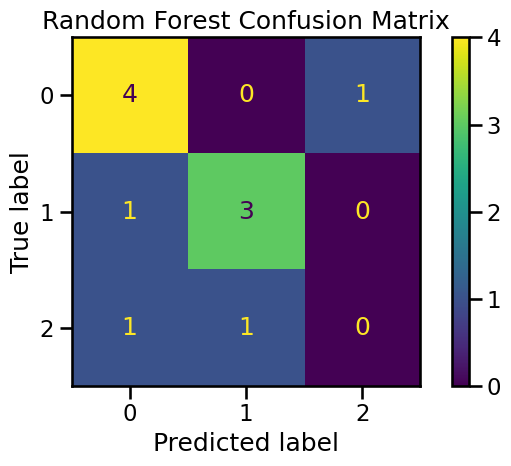

In [21]:


fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    ax=ax,
    values_format="d"
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 15. Compare model performance



In [22]:

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Weighted F1": [lr_f1, rf_f1]
}).sort_values(by="Weighted F1", ascending=False)

display(results)

,Model,Accuracy,Weighted F1
1,Random Forest,0.636364,0.603306
0,Logistic Regression,0.545455,0.448485


## 16. Interpretation




1. which model performed better,
2. whether structured demographic/admission features carried signal,
3. how richer features such as labs, vitals, or medications might improve prediction.

In [23]:


best_model_name = results.iloc[0]["Model"]
best_f1 = results.iloc[0]["Weighted F1"]

print(f"The best-performing model in this run was: {best_model_name}")
print(f"Best weighted F1-score: {best_f1:.4f}")
print()
print("Interpretation ideas:")
print("A stronger tree-based model may capture nonlinear clinical patterns better.")
print("If performance is moderate, that is expected because the tutorial uses simple structured features.")
print("More detailed clinical variables could improve prediction in future work.")

The best-performing model in this run was: Random Forest
Best weighted F1-score: 0.6033

Interpretation ideas:
A stronger tree-based model may capture nonlinear clinical patterns better.
If performance is moderate, that is expected because the tutorial uses simple structured features.
More detailed clinical variables could improve prediction in future work.


## 17. Limitations



### Key limitations
1. diabetes is identified using diagnosis codes,
2. this tutorial uses a small, interpretable feature set,
3. class imbalance may affect predictions,
4. results are educational and not for clinical deployment.

In [24]:


results_path = BASE_DIR / "diabetes_los_model_results.csv"
results.to_csv(results_path, index=False)
print("Saved model summary to:", results_path)

Saved model summary to: /content/drive/MyDrive/akr3222_hw4/diabetes_los_model_results.csv


## 18. Conclusion

This tutorial showed how to:
1. identify diabetic ICU patients,
2. clean and prepare structured MIMIC-III data,
3. define ICU length-of-stay categories,
4. train and evaluate machine learning models.

This creates a clear, teachable healthcare ML workflow.
